# Fiery results - epochs

## NB y- and x-axis should be inverted

In [1]:
# imports

import numpy as np
from os.path import join
from matplotlib import pyplot as plt
import pickle
from scipy.stats import norm

In [2]:
from helper import get_results, find_gaussians, find_gaussians_cal, get_models_in_rings, find_instance_centers, plot_seg, \
                   generate_rel_diagrams, rot, get_clusters

## 0. Helper functions and static variables

In [3]:
PATH_labels_pedestrians = "labels_val_epoch0_pedestrians"  # Folder name
PATH_res_pedestrians = "results_val_epoch1_pedestrians_e12" # Folder name

PATH_labels_vehicles = "labels_val"
PATH_res_vehicles = "results_val"

PATH_image = "images_val" # Folder name

FILE_label = "labels_val_%i.p"   # Single file name
FILE_res = "results_val_img%i.p"  # Single file name
FILE_image = "image_val_b%i_i%i_s%i_c%i.jpg"  # Single file name



## 1. Get results in the right format

### Generate data for pedestrians

In [4]:
if False:

    segm_ped_y, segm_ped_p, segm_ped_log, inst_ped_y = get_results(flip_input=True) #ys, preds,  # TODO we can do it faster? - Splitting batches appart

    np.savez("segm_results_pedestrains_e12_full_inst.npz", y=segm_ped_y, p=segm_ped_p, log=segm_ped_log, inst=inst_ped_y)

else:
    segm_ped_data = np.load("segm_results_pedestrains_e12_full_inst.npz")

    segm_ped_y = segm_ped_data["y"]
    segm_ped_p = segm_ped_data["p"]

In [5]:
inst_ped_y = segm_ped_data["inst"]

In [6]:
if False:

    center_ped_y, center_ped_p, _, _ = get_results(results_name = "instance_center", label_name = "centerness", flip_input=True, use_softmax = False) #ys, preds,  # TODO we can do it faster? - Splitting batches appart

    np.savez("center_results_pedestrains_e12_full.npz", y=center_ped_y, p=center_ped_p)

center_ped_data = np.load("center_results_pedestrains_e12_full.npz")

center_ped_y = segm_ped_data["y"]
center_ped_p = center_ped_data["p"]

In [7]:
segm_ped_y.shape

(5, 5119, 200, 200)

In [8]:
segm_ped_p.shape

(5, 5119, 200, 200)

In [9]:
center_ped_p.shape

(5, 5119, 200, 200)

In [10]:
inst_ped_y.shape

(5, 5119, 200, 200)

## 2. Generate input data from segmentation

In [11]:
nr_future=4
#idx = 200

## Pixel-wise calibration

In [12]:
if True:
    models_cal, masks_cal, (indices_val, indices_test) = \
        get_models_in_rings(segm_ped_p, segm_ped_y, nr_future = nr_future, random_state=1001)
    models_cal_c, masks_cal_c, (indices_val_c, indices_test_c) =  \
        get_models_in_rings(center_ped_p, center_ped_y, nr_future = nr_future, random_state=1001)

0
(1273635,)
1
(3854664,)
2
(6408072,)
3
(8994216,)
4
(20389413,)
0
(1273635,)
1
(3854664,)
2
(6408072,)
3
(8994216,)
4
(20389413,)


## Location uncertainty

In [13]:
if True:
    
    print("Nr_future:", nr_future)

    quantiles = []
    center = [99.5, 99.5]

    for count, idx in enumerate(indices_test):

        if count % 100 == 0:
            print(count)

        segm_cal_full = np.zeros(shape=masks_cal[0].shape)

        for model, mask in zip(models_cal, masks_cal):
            segm_cal = model.predict(segm_ped_p[nr_future, idx].flatten())
            segm_cal_2d = segm_cal.reshape(200,200)
            segm_cal_full[mask] = segm_cal_2d[mask]


        segm_p_new = segm_ped_p[nr_future, idx].copy()
        segm_p_cal_new = segm_cal_full.copy()
        center_ped_p_new = center_ped_p[nr_future, idx].copy()

        p, p_cal, dists, masks_gmm, pdfs = find_gaussians_cal(segm_p_new, segm_p_cal_new, center_ped_p_new, 
                                                                      multiplier = 100, conf_threshold=0.1, nms_kernel_size=3)
        cls = get_clusters(segm_ped_y[nr_future, idx])

        ## Match cls with predicted cls
        all_matches = []
        all_matches_cal = []

        if masks_gmm == None:
            continue

        angles = []

        for i, (pr, pr_cal, dist, m) in enumerate(zip(p, p_cal, dists, masks_gmm)):

            #print(pred_cl)

            dist_mean_re = dist.mean - center

            #print(dist_mean_re)

            angle = np.rad2deg(np.math.atan2(*dist_mean_re))
            #print(dist.mean)
            #print("Angle:", angle)

            angles.append(angle)

            all_matches.append([[pr], [pr_cal], [dist.mean], [angle], [], [], []])

            for n_cl, cl in enumerate(cls):
                matches = np.sum(m[np.array(cl)[:, 1], np.array(cl)[:, 0]])
                match_prob = matches/len(cl)

                if matches != 0:
                    all_matches[i][4].append(n_cl)
                    all_matches[i][5].append(match_prob)
                    #all_matches[i][4].append(dist.mean)

                    # Match found, rotate axes for norm distribution
                    dist_mean_new = rot(angle) @ dist_mean_re
                    cov_new = rot(angle) @ dist.cov @ rot(angle).T


                    #print(n_cl)
                    #print(cov_new)                

                    norm_x = norm(dist_mean_new[0], np.sqrt(cov_new[0,0]))
                    norm_y = norm(dist_mean_new[1], np.sqrt(cov_new[1,1]))

                    ann_xy = np.mean(cl, axis=0)[::-1]  # rotate axes
                    ann_xy_re = ann_xy - center
                    ann_xy_new = rot(angle) @ ann_xy_re

                    # TODO rotate the ann_xy and move according to zero (-99.5, -99.5)


                    qx = norm_x.cdf(ann_xy_new[0])
                    qy = norm_y.cdf(ann_xy_new[1])

                    all_matches[i][6].append(np.array([qx,qy]))


                    # TODO remove

                    dist_old = dist.mean
                    pdf_old = pdfs[i]
                    idx_old = idx

                    #break ## TODO Only check until first match?


        for res in all_matches:
            if len(res[-1]) != 0:
                quantiles.append(res[-1][0])

        #break
        
    quantiles = np.array(quantiles)
    np.savez("results_location_uncertainty_traj_09_23_22.npz", q=quantiles)

Nr_future: 4
0
100
200
300
400
500
600
700
800
900
1000
1100
1200
1300
1400
1500
1600
1700
1800
1900
2000
2100
2200
2300
2400
2500
2600
2700
2800
2900
3000
3100
3200
3300
3400
3500
3600
3700
3800
3900
4000


In [14]:
data_np = np.load("results_location_uncertainty_traj_09_23_22.npz")
quantiles = data_np["q"]

(array([901., 165., 120.,  96.,  78.,  75.,  79.,  66.,  74.,  65.,  67.,
         76.,  62.,  62.,  67.,  57.,  63.,  74.,  73.,  69.,  62.,  71.,
         67.,  89.,  84.,  81.,  81.,  74.,  84.,  76.,  69.,  77.,  72.,
         81.,  86., 104.,  95.,  84.,  84.,  90.,  83., 110.,  93.,  91.,
        120.,  81.,  95., 101.,  82.,  81.,  86.,  89., 115.,  91.,  94.,
        104.,  98.,  89., 100., 114., 100.,  99.,  87.,  89.,  82.,  89.,
         91.,  80.,  67.,  72.,  73.,  63.,  88.,  61.,  70.,  81.,  82.,
         91.,  57.,  61.,  70.,  59.,  59.,  68.,  67.,  62.,  59.,  69.,
         61.,  67.,  64.,  67.,  77.,  79.,  79.,  94.,  88., 105., 160.,
        768.]),
 array([1.28398444e-104, 1.00000000e-002, 2.00000000e-002, 3.00000000e-002,
        4.00000000e-002, 5.00000000e-002, 6.00000000e-002, 7.00000000e-002,
        8.00000000e-002, 9.00000000e-002, 1.00000000e-001, 1.10000000e-001,
        1.20000000e-001, 1.30000000e-001, 1.40000000e-001, 1.50000000e-001,
        1.6000

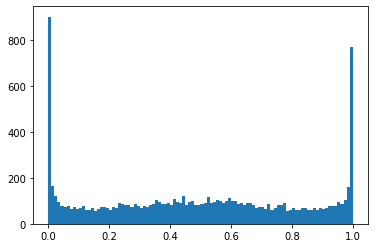

In [15]:
plt.hist(np.array(quantiles)[:, 0], bins = 100)  # X for width

(array([1054.,  213.,  174.,  144.,  113.,   97.,  113.,   81.,   99.,
          73.,   87.,   72.,   79.,   90.,   76.,   68.,   61.,   71.,
          78.,   82.,   60.,   81.,   75.,   73.,   82.,   58.,   63.,
          64.,   65.,   66.,   68.,   63.,   50.,   67.,   70.,   62.,
          62.,   55.,   65.,   70.,   64.,   58.,   57.,   59.,   69.,
          55.,   65.,   80.,   61.,   62.,   67.,   66.,   49.,   58.,
          68.,   49.,   62.,   71.,   57.,   69.,   71.,   64.,   71.,
          52.,   68.,   58.,   62.,   53.,   64.,   69.,   74.,   67.,
          45.,   51.,   66.,   65.,   69.,   59.,   73.,   54.,   51.,
          64.,   73.,   82.,   71.,   77.,   56.,   67.,   83.,   79.,
         102.,   87.,   89.,   88.,  117.,  135.,  141.,  191.,  233.,
        1091.]),
 array([2.7658642e-295, 1.0000000e-002, 2.0000000e-002, 3.0000000e-002,
        4.0000000e-002, 5.0000000e-002, 6.0000000e-002, 7.0000000e-002,
        8.0000000e-002, 9.0000000e-002, 1.0000000e-001, 1.

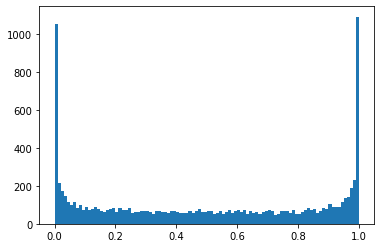

In [16]:
plt.hist(np.array(quantiles)[:, 1], bins = 100)  # y for distance

In [17]:
def rel_diag_quantiles(data, l = 100):
    qs = np.linspace(1/l, 1, l)
    plt.plot(qs, np.quantile(data, qs))
    plt.gca().set_aspect('equal', 'box')
    plt.title("QQ plot")

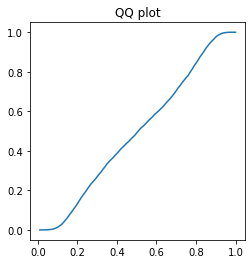

In [18]:
rel_diag_quantiles(np.array(quantiles)[:, 0])  # X for width

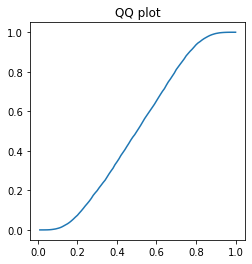

In [19]:
rel_diag_quantiles(np.array(quantiles)[:, 1])  # Y for distance

### For calibrated data

In [20]:
if True:

    print("Nr_future:", nr_future)

    quantiles_cal = []
    center = [99.5, 99.5]

    for count, idx in enumerate(indices_test):

        if count % 100 == 0:
            print(count)
        
        segm_cal_full = np.zeros(shape=masks_cal[0].shape)
        center_cal_full = np.zeros(shape=masks_cal_c[0].shape)

        for model, mask in zip(models_cal, masks_cal):
            segm_cal = model.predict(segm_ped_p[nr_future, idx].flatten())
            segm_cal_2d = segm_cal.reshape(200,200)
            segm_cal_full[mask] = segm_cal_2d[mask]

        for model_c, mask_c in zip(models_cal_c, masks_cal_c):
            center_cal = model_c.predict(center_ped_p[nr_future, idx].flatten())
            center_cal_2d = center_cal.reshape(200,200)

            #print("Uncal NLL:", log_loss(segm_ped_y[nr_future, idx].flatten(), segm_ped_p[nr_future, idx].flatten()))
            #print("Cal NLL:", log_loss(segm_ped_y[nr_future, idx].flatten(), segm_cal))

            center_cal_full[mask_c] = center_cal_2d[mask_c]

        center_p_cal = center_cal_full.copy()
        #segm_p_new = segm_ped_p[nr_future, idx].copy()
        segm_p_cal_new = segm_cal_full.copy()
        #center_ped_p_new = center_ped_p[nr_future, idx].copy()

        # TODO center_ped_p_cal?
        p, p_cal, dists, masks_gmm, pdfs = find_gaussians_cal(segm_p_cal_new, segm_p_cal_new, center_p_cal, 
                                                                      multiplier = 100, conf_threshold=0.1, nms_kernel_size=3)
        cls = get_clusters(segm_ped_y[nr_future, idx])

        ## Match cls with predicted cls
        all_matches = []
        all_matches_cal = []

        if masks_gmm == None:
            continue

        angles = []

        for i, (pr, pr_cal, dist, m) in enumerate(zip(p, p_cal, dists, masks_gmm)):

            #print(pred_cl)

            dist_mean_re = dist.mean - center

            #print(dist_mean_re)

            angle = np.rad2deg(np.math.atan2(*dist_mean_re))
            #print(dist.mean)
            #print("Angle:", angle)

            angles.append(angle)

            all_matches.append([[pr], [pr_cal], [dist.mean], [angle], [], [], []])

            for n_cl, cl in enumerate(cls):
                matches = np.sum(m[np.array(cl)[:, 1], np.array(cl)[:, 0]])
                match_prob = matches/len(cl)

                if matches != 0:
                    all_matches[i][4].append(n_cl)
                    all_matches[i][5].append(match_prob)
                    #all_matches[i][4].append(dist.mean)

                    # Match found, rotate axes for norm distribution
                    dist_mean_new = rot(angle) @ dist_mean_re
                    cov_new = rot(angle) @ dist.cov @ rot(angle).T


                    #print(n_cl)
                    #print(cov_new)                

                    norm_x = norm(dist_mean_new[0], np.sqrt(cov_new[0,0]))
                    norm_y = norm(dist_mean_new[1], np.sqrt(cov_new[1,1]))

                    ann_xy = np.mean(cl, axis=0)[::-1]  # rotate axes
                    ann_xy_re = ann_xy - center
                    ann_xy_new = rot(angle) @ ann_xy_re

                    # TODO rotate the ann_xy and move according to zero (-99.5, -99.5)


                    qx = norm_x.cdf(ann_xy_new[0])
                    qy = norm_y.cdf(ann_xy_new[1])

                    all_matches[i][6].append(np.array([qx,qy]))


                    # TODO remove

                    dist_old = dist.mean
                    pdf_old = pdfs[i]
                    idx_old = idx

                    #break ## TODO Only check until first match?


        for res in all_matches:
            if len(res[-1]) != 0:
                quantiles_cal.append(res[-1][0])

        #break
        
    quantiles_cal = np.array(quantiles_cal)
    np.savez("results_location_uncertainty_cal_traj_09_23_22.npz", q=quantiles_cal)        

Nr_future: 4
0
100
200
300
400
500
600
700
800
900
1000
1100
1200
1300
1400
1500
1600
1700
1800
1900
2000
2100
2200
2300
2400
2500
2600
2700
2800
2900
3000
3100
3200
3300
3400
3500
3600
3700
3800
3900
4000


In [21]:
data_np = np.load("results_location_uncertainty_cal_traj_09_23_22.npz")
quantiles_cal = data_np["q"]

(array([448.,  82.,  67.,  41.,  34.,  39.,  41.,  31.,  37.,  35.,  44.,
         34.,  47.,  38.,  49.,  47.,  30.,  42.,  37.,  37.,  46.,  49.,
         48.,  48.,  48.,  34.,  46.,  48.,  55.,  47.,  44.,  45.,  56.,
         55.,  44.,  49.,  42.,  53.,  42.,  25.,  49.,  46.,  56.,  49.,
         43.,  58.,  39.,  48.,  53.,  60.,  44.,  48.,  46.,  39.,  44.,
         55.,  44.,  53.,  49.,  48.,  53.,  44.,  46.,  41.,  42.,  52.,
         51.,  51.,  41.,  45.,  49.,  38.,  48.,  37.,  41.,  30.,  37.,
         33.,  38.,  32.,  38.,  50.,  39.,  43.,  33.,  33.,  22.,  42.,
         45.,  29.,  31.,  29.,  28.,  40.,  40.,  40.,  46.,  63.,  61.,
        389.]),
 array([1.29455645e-55, 1.00000000e-02, 2.00000000e-02, 3.00000000e-02,
        4.00000000e-02, 5.00000000e-02, 6.00000000e-02, 7.00000000e-02,
        8.00000000e-02, 9.00000000e-02, 1.00000000e-01, 1.10000000e-01,
        1.20000000e-01, 1.30000000e-01, 1.40000000e-01, 1.50000000e-01,
        1.60000000e-01, 1.7000

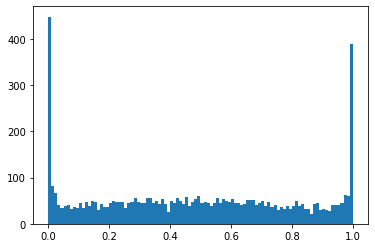

In [22]:
plt.hist(np.array(quantiles_cal)[:, 0], bins = 100)

(array([474.,  71.,  74.,  52.,  51.,  41.,  45.,  32.,  45.,  45.,  47.,
         40.,  46.,  45.,  49.,  34.,  39.,  43.,  44.,  37.,  46.,  39.,
         36.,  42.,  38.,  51.,  52.,  30.,  39.,  35.,  39.,  32.,  35.,
         46.,  44.,  43.,  43.,  50.,  34.,  25.,  41.,  32.,  28.,  41.,
         40.,  39.,  41.,  35.,  42.,  28.,  26.,  40.,  30.,  29.,  39.,
         44.,  26.,  36.,  39.,  36.,  43.,  34.,  36.,  37.,  44.,  30.,
         36.,  32.,  38.,  31.,  36.,  44.,  43.,  40.,  32.,  43.,  35.,
         44.,  38.,  39.,  41.,  35.,  33.,  57.,  33.,  50.,  43.,  55.,
         39.,  53.,  43.,  52.,  53.,  47.,  59.,  69.,  79.,  89., 113.,
        482.]),
 array([3.73886957e-76, 1.00000000e-02, 2.00000000e-02, 3.00000000e-02,
        4.00000000e-02, 5.00000000e-02, 6.00000000e-02, 7.00000000e-02,
        8.00000000e-02, 9.00000000e-02, 1.00000000e-01, 1.10000000e-01,
        1.20000000e-01, 1.30000000e-01, 1.40000000e-01, 1.50000000e-01,
        1.60000000e-01, 1.7000

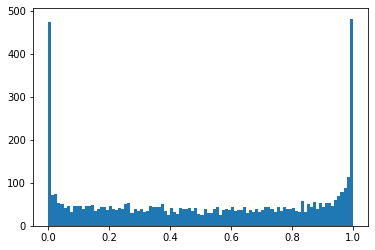

In [23]:
plt.hist(np.array(quantiles_cal)[:, 1], bins = 100)

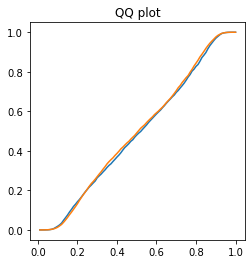

In [24]:
rel_diag_quantiles(np.array(quantiles_cal)[:, 0])  # X for width
rel_diag_quantiles(np.array(quantiles)[:, 0])  # X for width

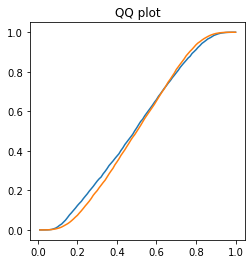

In [25]:
rel_diag_quantiles(np.array(quantiles_cal)[:, 1])  # Y for distance
rel_diag_quantiles(np.array(quantiles)[:, 1])  # X for width

## Debug

In [26]:
#assert False

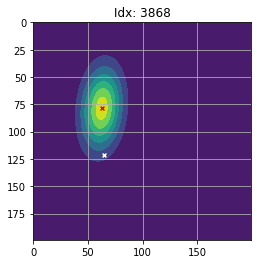

In [27]:
x, y = np.mgrid[0:200:1, 0:200:1]
pos = np.dstack((x, y))

fig2 = plt.figure()
ax2 = plt.gca()
#ax2 = fig2.add_subplot(111)
ax2.contourf(x, y, np.clip(np.sum([pdf_old], axis=0), 0, 0.01))  # For some reason 10x difference with segm mapping
#ax2.set_ylim([0,200])
plt.gca().invert_yaxis()

plt.scatter(*ann_xy, color = "white", s = 15, marker = "x")
plt.scatter(*dist_old, color = "red", s = 15, marker = "x")
plt.grid()
plt.title("Idx: %i" % idx_old)
ax2.set_aspect('equal', 'box')

In [28]:
ann_xy

array([ 64.5, 121. ])

In [29]:
ann_xy_new

array([35.87899559, 19.99869185])

In [30]:
dist_mean_new

array([-3.55271368e-15,  4.23640533e+01])

In [31]:
cov_new

array([[ 545.80504343, -177.49604461],
       [-177.49604461,  228.36522798]])

In [33]:
from scipy.stats import multivariate_normal

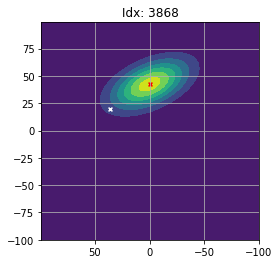

In [34]:
pdfs_new_angle = []

x, y = np.mgrid[-100:100:1, -100:100:1]
pos = np.dstack((x, y))

#cov_new = rot(angles[j]) @ dists[j].cov @ rot(angles[j])

rv = multivariate_normal(dist_mean_new, cov_new)


thr = rv.pdf([rv.mean[0] + 3*np.sqrt(rv.cov[0,0]), rv.mean[1] + 3*np.sqrt(rv.cov[1,1])])
pdfs_new_angle.append(rv.pdf(pos))

masks = []
segm_preds = []
#distributions

fig2 = plt.figure()
ax2 = plt.gca()
#ax2 = fig2.add_subplot(111)
ax2.contourf(x, y, np.clip(np.sum(pdfs_new_angle, axis=0), 0, 1))  # For some reason 10x difference with segm mapping
plt.scatter(*ann_xy_new, color = "white", s = 15, marker = "x")
plt.scatter(*dist_mean_new, color = "red", s = 15, marker = "x")

#ax2.set_ylim([0,200])
plt.gca().invert_xaxis()
plt.title("Idx: %i" % idx_old)
plt.grid()
ax2.set_aspect('equal', 'box')

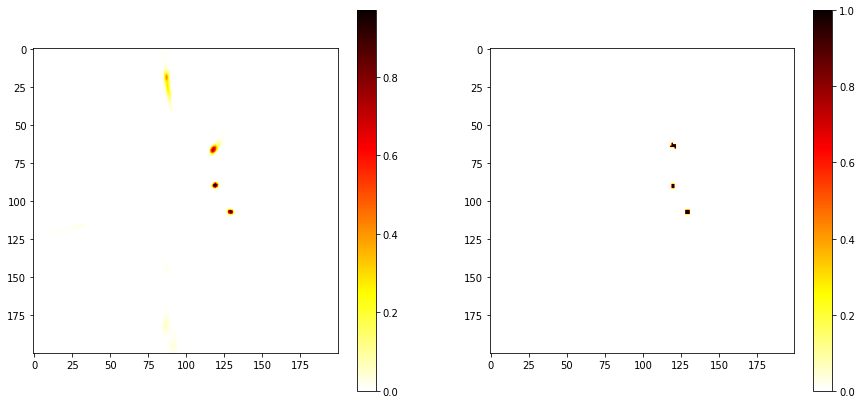

In [35]:
plot_seg(113, segm_ped_p, segm_ped_y)

In [36]:
rv.pdf(ann_xy_new)

0.00011467895299780593

In [37]:
qx

0.9377005718817389

In [38]:
qy

0.06943697876798287

In [39]:
norm_x.cdf(ann_xy_new[0])

0.9377005718817389

In [40]:
ann_xy_new

array([35.87899559, 19.99869185])

In [41]:
norm()

In [42]:
multivariate_normal()

In [43]:
norm_y.std()

15.111757938141077

In [44]:
cov_new

array([[ 545.80504343, -177.49604461],
       [-177.49604461,  228.36522798]])

In [45]:
norm_y.cdf(ann_xy_new[1])

0.06943697876798287